FOREST FIRE PREDICTION

STEP-1: IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

STEP-2: LOAD DATASET

In [2]:
df = pd.read_csv("/content/forestfires.csv")
print("Shape:", df.shape)
df.head()

Shape: (517, 13)


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


STEP-3:EXPLORE THE DATA

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [4]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


STEP-4:PRINT THE MISSING VALUES

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nFires with area > 0:", (df['area'] > 0).sum(), "out of", len(df))

Missing values per column:
X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

Fires with area > 0: 270 out of 517


Distribution of burned area (very skewed - most fires are small/zero)

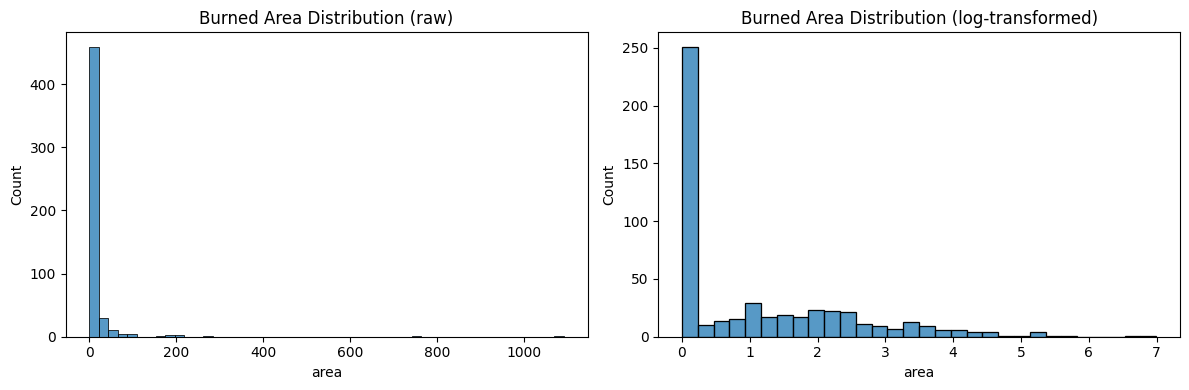

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['area'], bins=50, ax=axes[0])
axes[0].set_title("Burned Area Distribution (raw)")

sns.histplot(np.log1p(df['area']), bins=30, ax=axes[1])
axes[1].set_title("Burned Area Distribution (log-transformed)")
plt.tight_layout()
plt.show()

Correlation heatmap of numeric features

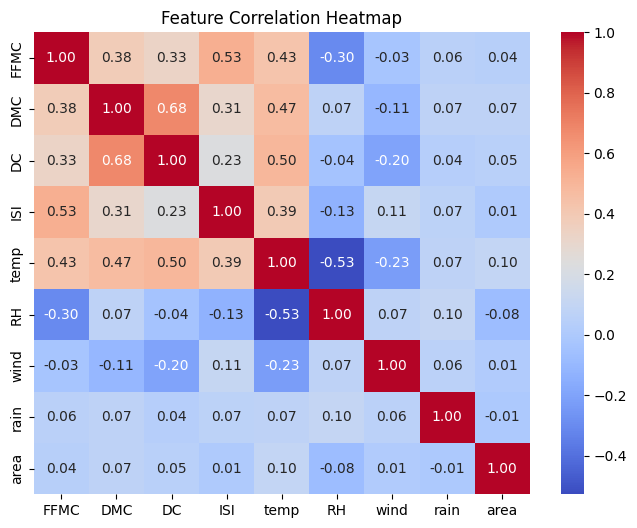

In [7]:
numeric_cols = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

Fires by month

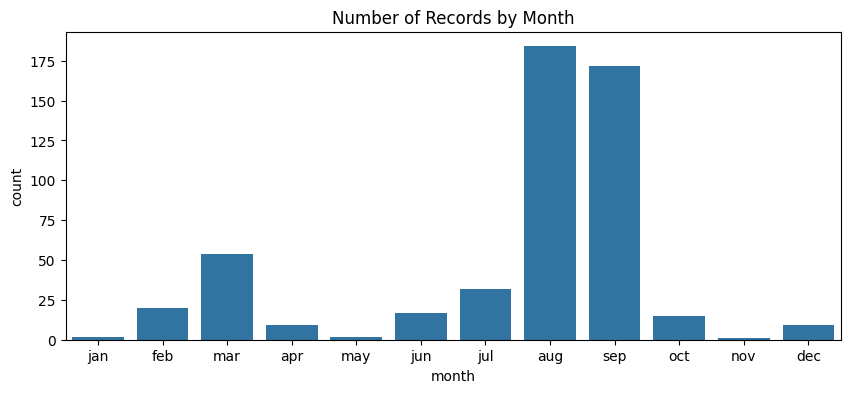

In [8]:

plt.figure(figsize=(10, 4))
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
sns.countplot(data=df, x='month', order=month_order)
plt.title("Number of Records by Month")
plt.show()


 Create a Binary Target
area is heavily skewed with lots of zeros/near-zeros, which makes it hard to regress directly for a quick project. We create a simpler binary label:

fire_occurred = 1 if area > 0 (a real fire happened)

fire_occurred = 0

In [9]:
df['fire_occurred'] = (df['area'] > 0).astype(int)
df['fire_occurred'].value_counts()


,count
fire_occurred,
1,270
0,247


 Encode Categorical Features & Select X / y

In [10]:
df_encoded = pd.get_dummies(df, columns=['month', 'day'], drop_first=True)

feature_cols = [c for c in df_encoded.columns if c not in ['area', 'fire_occurred']]
X = df_encoded[feature_cols]
y_class = df_encoded['fire_occurred']

print("Features used:", len(feature_cols))
X.head()

Features used: 27


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,month_may,month_nov,month_oct,month_sep,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,False,False,False,False,False,False,False,False,False,False
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,False,False,True,False,False,False,False,False,True,False
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,False,False,True,False,False,True,False,False,False,False
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,False,False,False,False,False,False,False,False,False,False
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,False,False,False,False,False,False,True,False,False,False


 Train/Test Split & Train a Classifier

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred))


Accuracy: 0.654

              precision    recall  f1-score   support

           0       0.63      0.66      0.65        50
           1       0.67      0.65      0.66        54

    accuracy                           0.65       104
   macro avg       0.65      0.65      0.65       104
weighted avg       0.65      0.65      0.65       104



CONFUSION MATRIX

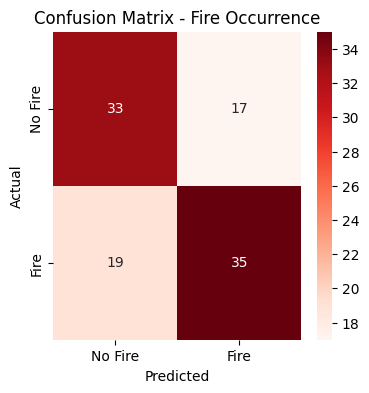

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['No Fire','Fire'], yticklabels=['No Fire','Fire'])
plt.title("Confusion Matrix - Fire Occurrence")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

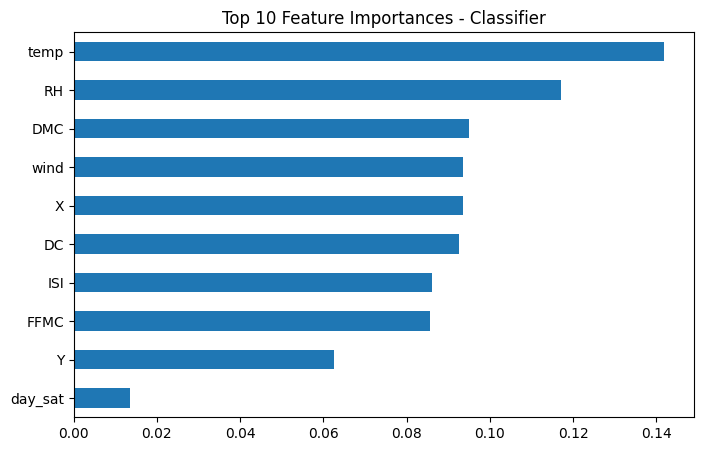

In [13]:
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances - Classifier")
plt.gca().invert_yaxis()
plt.show()

Predict Burned Area (Regression):
Instead of just yes/no, let's predict the actual severity (log-transformed area, since it's skewed).

In [14]:
y_reg = np.log1p(df_encoded['area'])  # log1p handles the zero values

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

reg = RandomForestRegressor(n_estimators=200, random_state=42)
reg.fit(X_train_r, y_train_r)

y_pred_r = reg.predict(X_test_r)
print("MAE:", round(mean_absolute_error(y_test_r, y_pred_r), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_r, y_pred_r)), 3))
print("R²:", round(r2_score(y_test_r, y_pred_r), 3))

MAE: 1.205
RMSE: 1.529
R²: -0.064


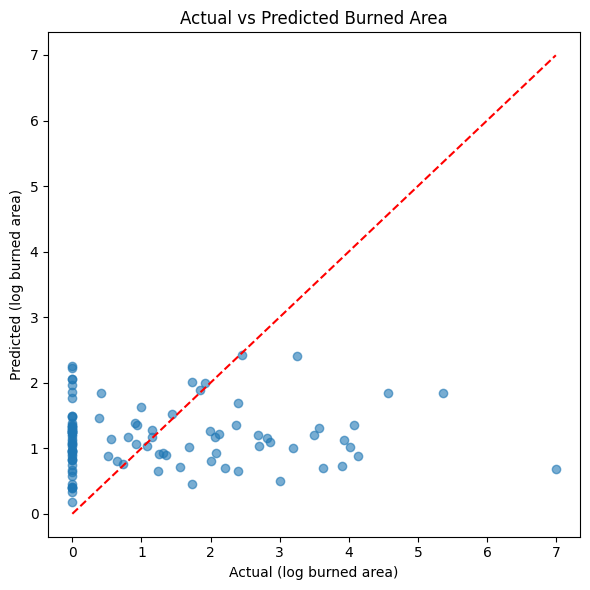

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.6)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
plt.xlabel("Actual (log burned area)")
plt.ylabel("Predicted (log burned area)")
plt.title("Actual vs Predicted Burned Area")
plt.tight_layout()
plt.show()


In [16]:
sample = pd.DataFrame([{
    'X': 7, 'Y': 5, 'FFMC': 90.0, 'DMC': 50.0, 'DC': 400.0, 'ISI': 9.0,
    'temp': 25.0, 'RH': 30, 'wind': 5.0, 'rain': 0.0
}])

# Add the same one-hot columns as training data (all zero = baseline month/day), then align
for col in feature_cols:
    if col not in sample.columns:
        sample[col] = 0
sample = sample[feature_cols]

pred_class = clf.predict(sample)[0]
pred_proba = clf.predict_proba(sample)[0][1]
pred_area = np.expm1(reg.predict(sample)[0])

print("Fire predicted?", "YES" if pred_class == 1 else "NO", f"(probability: {pred_proba:.2f})")
print(f"Estimated burned area: {pred_area:.2f} hectares")


Fire predicted? YES (probability: 0.56)
Estimated burned area: 2.12 hectares
